In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
X = df.drop('species', axis=1)
y = df['species']

In [6]:
# loas and fit the KNN classifier
from sklearn.neighbors import KNeighborsClassifier

Knn = KNeighborsClassifier(n_neighbors=5)
Knn.fit(X,y)

KNeighborsClassifier()

In [7]:
new_measurement = np.array([[5.1,3.5,1.4,0.2]])
Knn.predict(new_measurement)

D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['setosa'], dtype=object)

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
model = KNeighborsClassifier(n_neighbors=5)

In [21]:
# fit the data on the training data
model.fit(X_train,y_train)

KNeighborsClassifier()

In [22]:
y_pred = model.predict(X_test)

In [23]:
# evaluation of model
from sklearn.metrics import classification_report,confusion_matrix
print('Confusion Matrix : \n', confusion_matrix(y_test,y_pred))
print('Classification Report : \n',classification_report(y_test,y_pred))

Confusion Matrix : 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report : 
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



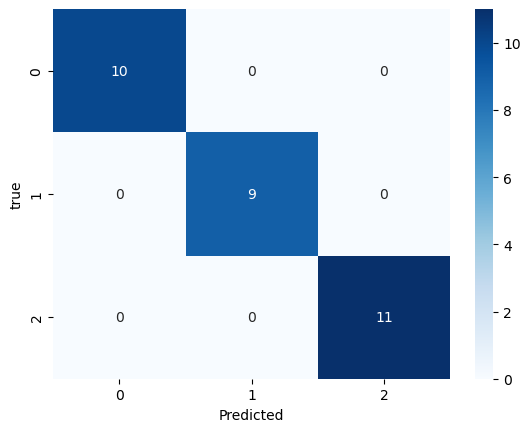

In [24]:
# plot the confusion marix
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('true')
plt.show()